# Problem Statement: **Optimization of AtliQ's Fashion Image Classifier**

### AtliQ Retail wants to develop a neural network model to classify fashion items from the **FashionMNIST** dataset. Your task is to optimize the model's performance by experimenting with different optimization algorithms.

Imports and CUDA

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

# Check if CUDA (GPU) is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu




---



**Step1**: Load and Sample the Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_subset_size = 10000
test_subset_size = 2000

100%|██████████| 26.4M/26.4M [00:06<00:00, 3.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 187kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]




---



**Step2**: Create Dataloaders

* batch size = 32

In [6]:
train_subset, _ = random_split(train_dataset, [train_subset_size, len(train_dataset) - train_subset_size])
test_subset, _ = random_split(test_dataset, [test_subset_size, len(test_dataset) - test_subset_size])

In [7]:
batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=True)

torch.Size([32, 1, 28, 28]) torch.Size([32])


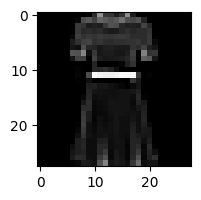

In [12]:
# Check a sample image in FashionMNIST Dataset
import matplotlib.pyplot as plt

for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

plt.figure(figsize=(2,2))
plt.imshow(images[7].cpu().squeeze(), cmap='gray')
plt.show()



---



**Step3**: Define the Neural Network

* Create a fully connected feed-forward neural network (no CNN).

Structure:
* Input layer: 784 neurons (28x28 image flattened).
* 1st hidden layer: 128 neurons with ReLU activation.
* 2nd hidden layer: 64 neurons with ReLU activation.
* Output layer: 10 neurons (one for each class) with Softmax activation.
* Use `CrossEntropyLoss `as Loss Function

Use `nn.Sequential`

In [14]:
import torch
import torch.nn as nn

# Define the model
class FashionNN(nn.Module):
    def __init__(self):
        super(FashionNN, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                      # Flatten 28x28 → 784
            nn.Linear(784, 128),               # Input layer → Hidden layer
            nn.ReLU(),                         # Activation
            nn.Linear(128, 64),                # Hidden layer 1
            nn.ReLU(),                         # Activation
            nn.Linear(64, 10),                 # Output layer
        )

    def forward(self, x):
        return self.network(x)

# Instantiate model
model = FashionNN()
print(model)

# Define loss function
loss_fn = nn.CrossEntropyLoss()  # Because we're using LogSoftmax as output


FashionNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)




---



**Step4**: Train and Evaluate with SGD

* set number of epochs to 10
* `lr` = 0.01
* momentum = 0.0




In [19]:
# Set number of epochs
num_epochs = 10

# Initialize the optimizer
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.0)

# Store loss for each epoch
epoch_losses = []

# Train the model for num_epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer_sgd.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer_sgd.step()

        running_loss += loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# Step 2: Calculate accuracy after all epochs
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy with SGD optimizer: {accuracy:.2f}%")


Epoch 1/10, Loss: 1.5333
Epoch 2/10, Loss: 0.7791
Epoch 3/10, Loss: 0.6398
Epoch 4/10, Loss: 0.5789
Epoch 5/10, Loss: 0.5408
Epoch 6/10, Loss: 0.5098
Epoch 7/10, Loss: 0.4865
Epoch 8/10, Loss: 0.4703
Epoch 9/10, Loss: 0.4542
Epoch 10/10, Loss: 0.4406
Accuracy with SGD optimizer: 81.15%


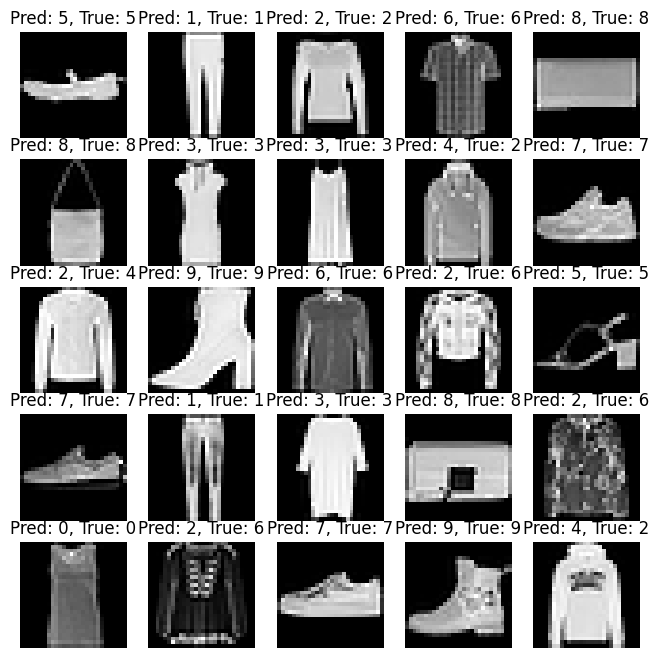

In [20]:
# Plot predictions vs true labels for the first 9 images
model.eval()
with torch.no_grad():
    # Grab a batch of test data
    images, labels = next(iter(test_loader))
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    # Plot the first 9 images with predictions and true labels
    plt.figure(figsize=(8, 8))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"Pred: {predicted[i].item()}, True: {labels[i].item()}")
        plt.axis('off')
    plt.show()



---



**Step5**: Train with SGD and Momentum

* set number of epochs to 10
* `lr` = 0.01
* momentum = 0.9

In [21]:
# Set number of epochs
num_epochs = 10

# Initialize the optimizer
optimizer_momentum = optim.SGD(model.parameters(), lr=0.01, momentum = 0.9)

# Store loss for each epoch
epoch_losses = []

# Train the model for num_epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer_momentum.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer_momentum.step()

        running_loss += loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# Step 2: Calculate accuracy after all epochs
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy with Momentum optimizer: {accuracy:.2f}%")


Epoch 1/10, Loss: 0.5204
Epoch 2/10, Loss: 0.4484
Epoch 3/10, Loss: 0.4060
Epoch 4/10, Loss: 0.3809
Epoch 5/10, Loss: 0.3554
Epoch 6/10, Loss: 0.3347
Epoch 7/10, Loss: 0.3244
Epoch 8/10, Loss: 0.3076
Epoch 9/10, Loss: 0.2890
Epoch 10/10, Loss: 0.2699
Accuracy with Momentum optimizer: 85.55%


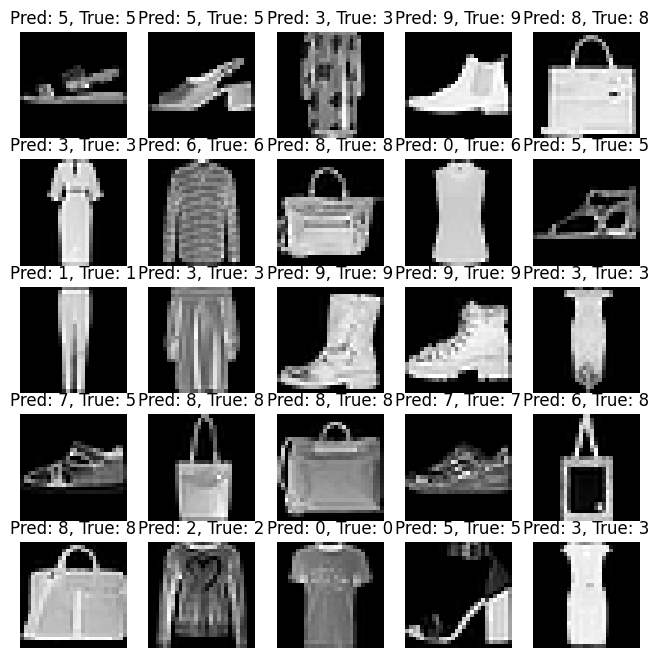

In [22]:
# Plot predictions vs true labels for the first 9 images
model.eval()
with torch.no_grad():
    # Grab a batch of test data
    images, labels = next(iter(test_loader))
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    # Plot the first 9 images with predictions and true labels
    plt.figure(figsize=(8, 8))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"Pred: {predicted[i].item()}, True: {labels[i].item()}")
        plt.axis('off')
    plt.show()



---



**Step6**: Training with RMS Prop

* set number of epochs to 10
* `lr` = 0.001
* alpha = 0.9

In [27]:
# Set number of epochs
num_epochs = 10

# Initialize the optimizer
optimizer_rms = optim.RMSprop(model.parameters(), lr=0.001, alpha=0.99, momentum=0.9)

# Store loss for each epoch
epoch_losses = []

# Train the model for num_epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer_rms.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer_rms.step()

        running_loss += loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# Step 2: Calculate accuracy after all epochs
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Accuracy with RMS optimizer: {accuracy:.2f}%")


Epoch 1/10, Loss: 1.3791
Epoch 2/10, Loss: 0.6731
Epoch 3/10, Loss: 0.5879
Epoch 4/10, Loss: 0.5330
Epoch 5/10, Loss: 0.5234
Epoch 6/10, Loss: 0.5259
Epoch 7/10, Loss: 0.4677
Epoch 8/10, Loss: 0.4813
Epoch 9/10, Loss: 0.4644
Epoch 10/10, Loss: 0.4660
Accuracy with RMS optimizer: 75.80%




---

